In [111]:
import pickle
import pandas as pd
import json
import pprint
from tqdm import tqdm
import numpy as np
import os
import sys
from IPython.display import display, Markdown
import logging
from pythonjsonlogger.json import JsonFormatter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from itertools import combinations

from pydantic import BaseModel, Field


from typing import Dict, List


In [112]:
from adr import adr
import utils

In [113]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.backend._sentencetransformers import SentenceTransformerBackend
from sentence_transformers import SentenceTransformer
from umap import UMAP


In [114]:
from bertopic.representation import OpenAI
from dotenv import load_dotenv
import openai
import tiktoken

# Configuring OpenAI (GPT)
print(load_dotenv())

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_MODEL_NAME"] =  os.getenv('OPENAI_MODEL_NAME') # 'gpt-4o-mini'
os.environ["EMBEDDINGS_MODEL"] = os.getenv("OPENAI_EMBEDDINGS_MODEL")
#OPENAI_API_KEY = None
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# print(os.environ["OPENAI_API_KEY"])
print(os.environ["OPENAI_MODEL_NAME"])
print(os.environ["EMBEDDINGS_MODEL"])

True
gpt-4.1-nano
text-embedding-3-small


In [115]:
logger = logging.getLogger(__name__)
logger.setLevel(logging.WARNING)

formatter = JsonFormatter(fmt='%(asctime)s %(levelname)s %(name)s %(message)s')
logHandler = logging.StreamHandler(sys.stdout)
logHandler.setFormatter(formatter)
logger.addHandler(logHandler)


# This is a dictionary with all the details of the ADRs, with a hierarchical organization
# that goes from the organization to its projects and finally the ADR files inside each project
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle' 

TOPICS_FOLDER = "saved_topicmodel"
TOPICS_DATAFRAME = os.path.join(TOPICS_FOLDER, 'topics_dataframe.csv')

In [116]:
class TopicResult(BaseModel):
    text: str = Field("Original (corpus) text for the ADR.")
    topics: List[int] = Field(..., description="A list of inferred topic ids for a text (ADR).")
    keywords: List[List[str]] = Field(..., description="A list of lists of keywords, each list characterizing the text and corresponding topic.")
    keybert_representation: List[str] = Field(..., description="A list of topic labels according to the KeyBERT representation of the text.")
    openai_representation: List[str] = Field(..., description="A list of topic labels according to the OpenAI representation of the text.")
    probabilities: List[float] = Field(..., description="A list of topic probabilities.")

In [117]:
class ADRTopicModel:

    def __init__(self):
        self.dict_adrs = {}
        self.adr_texts = []
        self.corpus = None
        self.all_adr_keys = None
        self.topic_model = None
        self.embeddings = None
        self.topic_distribution = None
    
    @staticmethod
    def _prune_corpus(docs: dict) -> tuple[list[str], list[str]]:
        """
        Prune the corpus of documents by removing spurious strings (if any)
        :param docs: dictionary with the documents
        :return: pruned corpus
        """    
        all_adr_keys = list(docs.keys())

        # Get the corpus of documents for topic modeling
        logger.info("Corpus (before):", len(docs))

        # Removing spurious strings (if any)
        corpus = [docs[(org, project, adr)] for org, project, adr in all_adr_keys]
        corpus = [s for s in corpus if (len(s) > 0) and not s.isspace()]

        keys_to_remove = []
        for k in all_adr_keys:
            candidate_adr = docs[k]
            if candidate_adr not in corpus:
                logger.info("Removing spurious ADR:", k)
                keys_to_remove.append(k)
        all_adr_keys = [k for k in all_adr_keys if k not in keys_to_remove] # Update the keys (for further reference)
        logger.info("Corpus (after):", len(corpus))

        return corpus, all_adr_keys

    def prepare_corpus(self, docs: dict=None):
        if docs is not None:
            self.dict_adrs = docs
        
        self.corpus, self.all_adr_keys = self._prune_corpus(self.dict_adrs)
    
    def configure_representation(self, use_openai=False):

        representation_model1 = KeyBERTInspired()

        self.open_ai_representation = use_openai

        if use_openai:
            # Tokenizer
            tokenizer= tiktoken.get_encoding("o200k_base") 
            # tokenizer= tiktoken.encoding_for_model(os.environ["OPENAI_MODEL_NAME"])

            prompt = """
            You are an assistant for a software developer that needs to analyze documents containing architectural design decisions.
            In this context, I have a software-related topic that affects the following documents:
            [DOCUMENTS]

            The topic is described by the following keywords: '[KEYWORDS]'.

            Based on the above information, can you assign a descriptive label of at most 7 words to the topic?
            Answer:
            """

            # Create your representation model
            self.client = openai.OpenAI(api_key=os.environ["OPENAI_API_KEY"])
            representation_model2 = OpenAI(
                self.client,
                model=os.environ["OPENAI_MODEL_NAME"], 
                delay_in_seconds=2, 
                chat=True,
                nr_docs=4,
                doc_length=100,
                tokenizer=tokenizer,
                prompt=prompt
            )
        
        if not use_openai:
            self.representation_model = {
                "Main": representation_model1, # KeyBERT
            }
        else:
            self.representation_model = {
                "Main": representation_model1, # KeyBERT
                "OpenAI": representation_model2 # OpenAI-based
            }

    def configure_embeddings(self, language='english', predefined_embedding_model='all-MiniLM-L6-v2', metric='cosine'):
        self.vectorizer_model = CountVectorizer(stop_words=language)

        # Pre-calculate embeddings
        self.embedding_model = SentenceTransformer(predefined_embedding_model)
        self.embeddings = None

        self.umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric=metric, random_state=42)

    def build(self, n_topics=None, use_openai=True) -> pd.DataFrame:

        logger.info("Creating new topic model...")
        self.configure_representation(use_openai=use_openai)
        self.configure_embeddings()
        
        self.topic_model = BERTopic(embedding_model=self.embedding_model, 
                        umap_model=self.umap_model,
                        representation_model=self.representation_model,
                        vectorizer_model=self.vectorizer_model,
                        nr_topics='auto', # It tries to find a reduced number of topics
                        verbose=True)
        
        logger.info("Fitting topic model to corpus...")
        self.topics = self.topic_model.fit_transform(self.corpus) # This takes around 5 minutes
        n = len(self.topic_model.get_topics())
        logger.info("Topics:", n)
        self.topic_distribution = None

        # Further reduce topics. Only if we want to give a specific number of topics
        if n_topics is not None:
            logger.info("Reducing topics to:", n_topics)
            self.topic_model.reduce_topics(self.corpus, nr_topics=n_topics)
            n = len(self.topic_model.get_topics())
            logger.info("Reduced topics:", n)
        
        self.topics_df = self.topic_model.get_topic_info()

        if use_openai:
            self.openai_topics = [x[0].strip('"') for x in self.topics_df['OpenAI'].tolist()]
            self.topic_model.set_topic_labels(topic_labels=self.openai_topics)

        return self.topics_df

    def load(self, folder: str, predefined_embedding_model='all-MiniLM-L6-v2', corpus_file: str='corpus.json') -> pd.DataFrame | None:
        if os.path.exists(folder):
            logger.info("Loading existing topic model...")
            self.topic_distribution = None
            self.configure_embeddings()
            
            # Retrieve corpus
            relative_path = os.path.join(folder, corpus_file)
            try:
                with open(relative_path, 'r') as f:
                    self.corpus = json.load(f)
                logger.info(f"Successfully loaded data from {relative_path}")
                # print(f"Loaded data: {loaded_data}")
            except FileNotFoundError:
                logger.error(f"{relative_path} not found.")
            except json.JSONDecodeError:
                logger.error(f"Could not decode JSON from {relative_path}.")

            embedding_model_st = SentenceTransformerBackend(predefined_embedding_model) 
            loaded_model = BERTopic.load(folder, embedding_model=embedding_model_st) #embedding_model_openai)
            self.topic_model = loaded_model
            n = len(self.topic_model.get_topics())
            logger.info("Topics:", n)
            self.topics_df = self.topic_model.get_topic_info()
            if 'OpenAI' in self.topics_df.columns:
                self.open_ai_representation = True
                self.openai_topics = [x[0].strip('"') for x in self.topics_df['OpenAI'].tolist()]
                self.topic_model.set_topic_labels(topic_labels=self.openai_topics)
            else:
                self.open_ai_representation = False

            return self.topics_df
        else:
            logger.error("Topic model folder does not exist (no topic model was created):", folder)
            return None


    def persist(self, folder: str, dataframe_file: str='topics_dataframe.csv', corpus_file: str='corpus.json'):
        if not os.path.exists(folder):
            os.makedirs(folder)

        logger.info(f"Saving newly-created topic model... {folder}")
        self.topic_model.save(folder, serialization="safetensors", save_ctfidf=True, save_embedding_model=self.embedding_model)
        
        relative_path = os.path.join(folder, dataframe_file)
        self.topics_df.to_pickle(relative_path.replace('.csv', '.pickle'))
        
        # Persist corpus as a JSON file
        relative_path = os.path.join(folder, corpus_file)
        try:
            with open(relative_path, 'w') as f:
                json.dump(self.corpus, f)
            logger.info(f"Successfully wrote corpus to {relative_path}")
        except IOError as e:
            logger.error(f"Error writing to file: {e}")
        
    
    def get_topk_topics(self, k: int=20) -> pd.DataFrame:
        top20_topics = self.topics_df.sort_values(by="Count", ascending=False).reset_index(drop=True).head(k) # Top 20 topics
        return top20_topics
    
    def get_topic_labels(self, representation='Main') -> list[str]:
        if representation == 'Main' or not self.open_ai_representation:
            return list(self.topic_model.topic_labels_.values())
        elif representation == 'OpenAI' and self.open_ai_representation:
            return self.openai_topics
        else:
            logger.warning("Unknown representation for topic labels:", representation)
            return []
    
    def show_topic_map(self, k: int=20, suppress_title=False, recompute_embeddings=False):
        if (self.embeddings is None) or recompute_embeddings:
            self.embeddings = self.embedding_model.encode(self.corpus, show_progress_bar=True)

        first_20_topics = list(range(-1,k))
        n_adrs = len(self.corpus)
        n_topics = len(self.topic_model.get_topics())
        title =  "Top-{} Topics in ADRs (ADRs: {} - Topics: {})".format(k, n_adrs, n_topics) if not suppress_title else None
        fig = self.topic_model.visualize_document_datamap(self.corpus, embeddings=self.embeddings, custom_labels=True, topic_prefix=True, topics=first_20_topics,
                                            title=title, #"Top-20 Topics in ADRs (ADRs: {} - Topics: {})".format(n_adrs, n_topics), 
                                            datamap_kwds={"label_over_points": True,  
                                                            #"label_font_size": 11,
                                                            "dynamic_label_size": True, "max_font_size": 18, "min_font_size": 9
                                                            })   

    def show_wordcloud(self, topic_id, max_words=1000):
        text = {word: value for word, value in self.topic_model.get_topic(topic_id)}
        wc = WordCloud(background_color="white", max_words=max_words)
        wc.generate_from_frequencies(text)
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.show()    
    
    def get_relevant_documents_for_topic(topic_id, threshold=0.5, recompute_distribution=False):
        """
        Get the most relevant documents for a given topic.
        :param topic_model: BERTopic model
        :param corpus: list of documents
        :param topic_id: topic id
        :param n: number of documents to return
        :return: list of tuples (document, probability)
        """  
        if (self.topic_distribution is None) or recompute_distribution:
            self.topic_distribution, _ = self.topic_model.approximate_distribution(self.corpus)
        
        # Get the probabilities of the topic in each document
        topic_probabilities = self.topic_distribution[:, topic_id]

        # Identify documents where the topic has a significant probability (e.g., > 0.1)
        affected_documents = [(doc_idx, prob) for doc_idx, prob in enumerate(topic_probabilities) if prob > threshold]
        # Order by probability
        affected_documents = sorted(affected_documents, key=lambda x: x[1], reverse=True)

        return affected_documents
    
    def get_topic_words(self, topic_id, threshold=0.3) -> List[str]:
        list_keywords = self.topic_model.get_topic(topic_id)
        return [x[0] for x in list_keywords if x[1] >= threshold]
    
    def get_topics_probabilities_per_document(self, doc: str, threshold=0.0):
        probabilities = self.topic_model.approximate_distribution([doc])
        document_probabilities = probabilities[0][0]

        topic_info_df = self.topic_model.get_topic_info()
        # Filter out the outlier topic (-1)
        valid_topics = topic_info_df[topic_info_df['Topic'] != -1]
        topic_ids = valid_topics['Topic'].tolist()
        
        new_topics = []
        new_probs = []
        for topic_id, prob in zip(topic_ids, document_probabilities):
            if prob > threshold:
                new_topics.append(topic_id)
                new_probs.append(prob)

        return new_topics, new_probs


    def predict(self, adr_text: str, as_dict=True, metadata=None, multiple_topics=False) -> Dict:

        if multiple_topics:
            new_topics, new_probs = self.get_topics_probabilities_per_document(adr_text)
        else:
            new_topics, new_probs = self.topic_model.transform(adr_text)
            new_topics = new_topics.tolist()
            new_probs = new_probs.tolist()
        
        all_keybert_labels = list(self.topic_model.topic_labels_.values())
        keybert_labels = [all_keybert_labels[t] for t in new_topics]
        keywords = [self.get_topic_words(t, threshold=0.0) for t in new_topics]
        
        openai_labels = []
        if self.open_ai_representation:
            openai_labels = [self.openai_topics[t] for t in new_topics]

        result = TopicResult(text=adr_text, topics=new_topics, keywords=keywords, keybert_representation=keybert_labels, openai_representation=openai_labels, probabilities=new_probs)    
        if as_dict:
            json_string = result.model_dump_json()
            result = json.loads(json_string)
            if metadata is not None:
                result['metadata'] = metadata
            return result
        else:
            return result
    
    def predict_batch(self, adr_texts: Dict[str,str], organization=None, project=None, as_dict=True, json_file=None, multiple_topics=False) -> List[Dict]:
        
        if multiple_topics:
            new_topics = []
            new_probs = []
            for text in adr_texts:
                nt, np = self.get_topics_probabilities_per_document(text)
                new_topics.append(nt)
                new_probs.append(np)
        else:
            new_topics, new_probs = self.topic_model.transform(list(adr_texts.values()))
            new_topics = new_topics.tolist()
            new_probs = new_probs.tolist()

        results = []
        all_keybert_labels = list(self.topic_model.topic_labels_.values())
        for text, topics, probs in tqdm(zip(adr_texts, new_topics, new_probs), desc="Inferring topics for ADRs"):
            if isinstance(topics, list):
                keybert_labels = [all_keybert_labels[t] for t in topics]
                keywords = [self.get_topic_words(t, threshold=0.0) for t in topics]
                if self.open_ai_representation:
                    openai_labels = [self.openai_topics[t] for t in topics]
                topics_ = topics
                probs_ = probs
            else:
                keybert_labels = [all_keybert_labels[topics]]
                keywords = [self.get_topic_words(topics, threshold=0.0)]
                openai_labels = []
                if self.open_ai_representation:
                    openai_labels = [self.openai_topics[topics]]  
                topics_ = [topics]   
                probs_ = [probs]
            
            result = TopicResult(text=text, topics=topics_, keywords=keywords, keybert_representation=keybert_labels, openai_representation=openai_labels, probabilities=probs_)    
            if as_dict:
                json_string = result.model_dump_json()
                result = json.loads(json_string)
            results.append(result)
        
        # Add metadata of the ADR (name, project, organization), if provided
        if as_dict and organization is not None and project is not None:
            results = [{**res, 'metadata': {'organization': organization, 'project': project, 'adr_key': adr_key}} for res, adr_key in zip(results, adr_texts.keys())]

        if (json_file is not None) and as_dict and (len(results) > 0):
            ADRTopicModel.save_results(results, json_file)
        
        return results

    
    @staticmethod
    def save_results(classifications: List[Dict], json_file: str):
        # Open the file and write the data
        try:
            with open(json_file, 'w') as json_file:
                json.dump(classifications, json_file, indent=4) # The indent=4 makes the file easy to read
        except IOError as e:
            print(f"Error saving file: {e}")
        logger.info(f"Classifications saved to {json_file}")
    
    def compute_topic_coherence(self, top_n=20) -> float:
        topics = self.topic_model.get_topics()
        if -1 in topics:
            del topics[-1]
        
        coherence_scores = []
        for topic_id in topics:
            words = [word for word, _ in topics[topic_id][:top_n]]
            embeddings = self.embedding_model.encode(words)
            
            # Compute pairwise cosine similarities
            sim_matrix = np.zeros((len(words), len(words)))
            for i in range(len(words)):
                for j in range(i+1, len(words)):
                    sim = np.dot(embeddings[i], embeddings[j]) / (
                        np.linalg.norm(embeddings[i]) * np.linalg.norm(embeddings[j])
                    )
                    sim_matrix[i][j] = sim
            avg_sim = np.mean(sim_matrix[np.triu_indices(len(words), k=1)])
            coherence_scores.append(avg_sim) # Mean similarity for the topic
        
        return np.mean(coherence_scores) # Mean similarity for all topics

    def compute_topic_diversity(self, top_n=20) -> float:
        # Exclude outlier topic (-1) if present
        topics = self.topic_model.get_topics()
        if -1 in topics:
            del topics[-1]
        
        # Extract top words for each topic
        topic_words = [set([word for word, _ in topics[topic][:top_n]]) for topic in topics]
        
        # Compute pairwise Jaccard similarities
        jaccard_sims = []
        for t1, t2 in combinations(topic_words, 2):
            intersection = len(t1 & t2)
            union = len(t1 | t2)
            jaccard_sim = intersection / union if union != 0 else 0
            jaccard_sims.append(jaccard_sim)
        
        # Average similarity and compute diversity
        avg_sim = sum(jaccard_sims) / len(jaccard_sims)
        diversity = 1 - avg_sim
        return diversity

---

In [118]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

547 projects/organizations?


In [119]:
def count_adrs(projects):
    count_adrs = 0
    for org, project in projects:
        adrs = dict_adrs[org][project]
        count_adrs += len(adrs)
    return count_adrs


projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

print("Total number of ADRs: ", count_adrs(projects_dict['all_projects']))
print("Total number of valid ADRs: ", count_adrs(valid_projects))

organizations:   0%|          | 0/547 [00:00<?, ?it/s]

Total number of ADRs:  6061
Total number of valid ADRs:  4316


In [120]:
def get_text_column(df_texts,column='original_text'):
    tt = df_texts[column]
    if isinstance(tt.values[0],str):
        return tt.values.tolist()
    tt = [' '.join(x) for x in tt]
    return tt

def get_adr_texts(adrs_dict):
    """
    Get the text of the ADRs
    :param adrs_dict: dictionary with the ADRs
    :return: list of strings with the text of the ADRs
    """
    texts = []
    for org in adrs_dict.keys():
        for proj in adrs_dict[org].keys():
            adrs = list(adrs_dict[org][proj].values())
            texts.extend(adrs)
    return texts

docs = utils.get_documents(valid_projects, dict_adrs, verbose=False, field='content')
print("Number of documents (cleaned ADRs): ", len(docs))

Number of documents (cleaned ADRs):  4316


In [121]:
adr_topic_model = ADRTopicModel()
# adr_topic_model.prepare_corpus(docs)

In [122]:
# adr_topic_model.build(use_openai=True)
adr_topic_model.load(TOPICS_FOLDER)

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,1514,-1_aws_deployment_cloud_services,Cloud Infrastructure and Deployment Decision-M...,"[aws, deployment, cloud, services, platform, s...",[Cloud Infrastructure and Deployment Decision-...,NaN
1,0,407,0_publishing_database_metadata_api,Software Architecture Decisions and Data Persi...,"[publishing, database, metadata, api, db, stor...",[Software Architecture Decisions and Data Pers...,NaN
2,1,257,1_fxa_jsx_framework_styles,Frontend architecture and UI component redesign,"[fxa, jsx, framework, styles, react, webpack, ...",[Frontend architecture and UI component redesign],NaN
3,2,213,2_architecture_decision_record_adrs_adr_archit...,Architectural Decision Records (ADR) Generatio...,"[architecture_decision_record, adrs, adr, arch...",[Architectural Decision Records (ADR) Generati...,NaN
4,3,109,3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,"[kubernetes, kubectl, pods, pod, ingress, aws,...",[Kubernetes ingress and resource management st...,NaN
...,...,...,...,...,...,...,...
68,67,12,67_microservices_microservice_monolithic_services,Software Architecture Decisions and Frameworks,"[microservices, microservice, monolithic, serv...",[Software Architecture Decisions and Frameworks],NaN
69,68,12,68_protocol_secrecy_otr_otrv4,Secure messaging protocols with key exchange a...,"[protocol, secrecy, otr, otrv4, otrv3, rfc, en...",[Secure messaging protocols with key exchange ...,NaN
70,69,11,69_domains_app_domain_internalrootdomain_dns,Internal DNS and Domain Management for Cloud P...,"[domains, app_domain, internalrootdomain, dns,...",[Internal DNS and Domain Management for Cloud ...,NaN
71,70,11,70_blobstore_blobstodelete_storage_blobs,Blob storage optimization and deduplication st...,"[blobstore, blobstodelete, storage, blobs, sto...",[Blob storage optimization and deduplication s...,NaN


In [123]:
# adr_topic_model.perist(TOPICS_FOLDER)

In [124]:
adr_topic_model.get_topic_labels()

['-1_aws_deployment_cloud_services',
 '0_publishing_database_metadata_api',
 '1_fxa_jsx_framework_styles',
 '2_architecture_decision_record_adrs_adr_architectural',
 '3_kubernetes_kubectl_pods_pod',
 '4_branches_releases_branching_branch',
 '5_docker_dockerfiles_dockerfile_containers',
 '6_apis_api_swagger_openapi',
 '7_testcontainers_testing_tests_testharness',
 '8_evidence_attacks_validators_consensus',
 '9_cosmos_sdk_protobuf_compatibility',
 '10_authentication_oauth2_authenticate_oauth',
 '11_aws_s3_uploading_uploads',
 '12_plugins_plugin_elektra_global',
 '13_python_pip_versions_py',
 '14_elasticsearch_lucene_searches_searching',
 '15_wikibaseclient_wikibaselexeme_wikibaserepo_wikibase',
 '16_secrets_kubernetes_vault_encrypt',
 '17_eclipse_xml_epl_java',
 '18_cassandramessageidmapper_cassandramessagemapper_imapuidtable_messageidtable',
 '19_authnrequests_authnrequest_saml_saml2',
 '20_frontend_webjars_hmrc_webjar',
 '21_attribute_specification_describes_decisions',
 '22_logging_lo

In [125]:
adr_topic_model.get_topic_labels(representation='OpenAI')

['Cloud Infrastructure and Deployment Decision-Making',
 'Software Architecture Decisions and Data Persistence',
 'Frontend architecture and UI component redesign',
 'Architectural Decision Records (ADR) Generation and Documentation',
 'Kubernetes ingress and resource management strategies',
 'Software Release Management and Branching Strategies',
 'Containerized CI/CD workflows and deployment processes',
 'API Design, Versioning, and Specification Management',
 'Software Testing Strategies and Database Handling',
 'Blockchain Evidence and Consensus Mechanisms',
 'Cosmos SDK Module Interactions and Encoding Strategies',
 'User Authentication and Authorization Mechanisms',
 'AWS S3-Based File Uploads and Access Control',
 'Elektra Plugin Architecture and Customization Strategies',
 'Python version support and migration strategies',
 'Advanced Search Architecture and Indexing Strategies',
 'Wikibase Architecture, Releases, Security, and Maintenance',
 'Secrets management and secure confi

In [126]:
# adr_topic_model.show_topic_map()

In [127]:
new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 

adr_topic_model.predict(new_doc, multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-24 19:20:16,690 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


{'text': 'Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that\'s already been done making these easy to use and secure by default. There\'s a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.',
 'topics': [19],
 'keywords': [['aut

In [128]:
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

In [131]:
adr_topic_model.predict_batch(adrs_to_classify, organization='LBHackney-IT', project='remultiform', multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-24 19:21:56,141 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
Inferring topics for ADRs: 10it [00:00, 12531.53it/s]


[{'text': '0001-record-architecture-decisions.md',
  'topics': [2],
  'keywords': [['architecture_decision_record',
    'adrs',
    'adr',
    'architectural',
    'architecture',
    'documenting',
    'documentation',
    'tools',
    'describes',
    'record']],
  'keybert_representation': ['1_fxa_jsx_framework_styles'],
  'openai_representation': ['Frontend architecture and UI component redesign'],
  'probabilities': [0.944305956363678],
  'metadata': {'organization': 'LBHackney-IT',
   'project': 'remultiform',
   'adr_key': '0001-record-architecture-decisions.md'}},
 {'text': '0002-use-typescript.md',
  'topics': [25],
  'keywords': [['typescript',
    'types',
    'type',
    'typegoose',
    'documentation',
    'developers',
    'javascript',
    'proptypes',
    'ts',
    'coffeescript']],
  'keybert_representation': ['24_p2p_libp2p_protocol_peer'],
  'openai_representation': ['Peer-to-Peer Networking and Protocol Refactoring'],
  'probabilities': [0.8821244835853577],
  'met

---

In [20]:
topic_model = adr_topic_model.topic_model

In [21]:
topic_model.visualize_hierarchy(custom_labels=False) # Topic hierarchy to check for spurious topics (i.e., irrelevant contents)

In [22]:
# For ADR contents (only)
# topics_to_merge = [-1, 3, 22, 23] # Spurious topics (e.g., ADR template) 
# topic_model.merge_topics(corpus, topics_to_merge) # It can take a while

### Visualization of Documents

In [23]:
n_adrs = len(adr_topic_model.corpus)
n_topics = len(adr_topic_model.topics_df)
print("Number of ADRs:", n_adrs)
print("Number of topics:", n_topics)

Number of ADRs: 4312
Number of topics: 73


In [24]:
first_20_topics = adr_topic_model.get_topk_topics(20)
first_20_topics

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,1514,-1_aws_deployment_cloud_services,Cloud Infrastructure and Deployment Decision-M...,"[aws, deployment, cloud, services, platform, s...",[Cloud Infrastructure and Deployment Decision-...,NaN
1,0,407,0_publishing_database_metadata_api,Software Architecture Decisions and Data Persi...,"[publishing, database, metadata, api, db, stor...",[Software Architecture Decisions and Data Pers...,NaN
2,1,257,1_fxa_jsx_framework_styles,Frontend architecture and UI component redesign,"[fxa, jsx, framework, styles, react, webpack, ...",[Frontend architecture and UI component redesign],NaN
3,2,213,2_architecture_decision_record_adrs_adr_archit...,Architectural Decision Records (ADR) Generatio...,"[architecture_decision_record, adrs, adr, arch...",[Architectural Decision Records (ADR) Generati...,NaN
4,3,109,3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,"[kubernetes, kubectl, pods, pod, ingress, aws,...",[Kubernetes ingress and resource management st...,NaN
5,4,108,4_branches_releases_branching_branch,Software Release Management and Branching Stra...,"[branches, releases, branching, branch, commit...",[Software Release Management and Branching Str...,NaN
6,5,100,5_docker_dockerfiles_dockerfile_containers,Containerized CI/CD workflows and deployment p...,"[docker, dockerfiles, dockerfile, containers, ...",[Containerized CI/CD workflows and deployment ...,NaN
7,6,84,6_apis_api_swagger_openapi,"API Design, Versioning, and Specification Mana...","[apis, api, swagger, openapi, documentation, s...","[API Design, Versioning, and Specification Man...",NaN
8,7,69,7_testcontainers_testing_tests_testharness,Software Testing Strategies and Database Handling,"[testcontainers, testing, tests, testharness, ...",[Software Testing Strategies and Database Hand...,NaN
9,8,68,8_evidence_attacks_validators_consensus,Blockchain Evidence and Consensus Mechanisms,"[evidence, attacks, validators, consensus, pro...",[Blockchain Evidence and Consensus Mechanisms],NaN


In [25]:
# embeddings = adr_topic_model.embedding_model.encode(adr_topic_model.corpus, show_progress_bar=True)

# It works only if the number of topics is not too high
# topic_model.visualize_document_datamap(adr_topic_model.corpus, embeddings=embeddings, 
#                                        interactive=True, custom_labels=True, topics=first_20_topics,
#                                        topic_prefix=True, enable_search=True, title="Top-20 Topics in ADRs") 

### Visualization of Topics

In [26]:
fig = topic_model.visualize_topics(custom_labels=True, title="Topic Mapping (Top 20 Topics)", top_n_topics=20) 
fig

In [27]:
topic_model.visualize_barchart(custom_labels=False, top_n_topics=20, title="Top 20 Topics in ADRs") # It can be saved as a PNG file

In [28]:
topic_model.visualize_heatmap() # Topic similarity

### Hierarchies

In [29]:
topic_model.visualize_hierarchy(custom_labels=False) # Topic hierarchy

### World Cloud

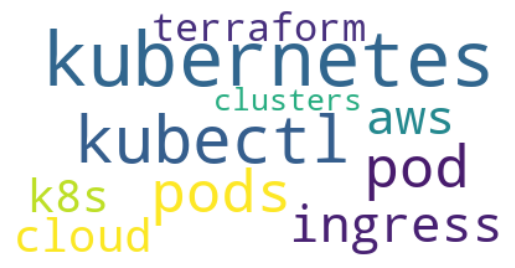

In [30]:
# Show wordcloud
adr_topic_model.show_wordcloud(topic_id=3)

In [31]:
# New documents to predict
new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 
result = adr_topic_model.predict(new_doc, as_dict=False)

color_name_markdown = '<span style="color: orange;">' + new_doc + '</span>'
display(Markdown(color_name_markdown))

print(f"Topics: {result.topics}") # e.g., [0, 1]
print(f"Probabilities: {result.probabilities}") # e.g., [0.9, 0.8]
print("-----")
threshold = 0.1
labels = topic_model.get_topic_info()['CustomName'].tolist()
for topic, prob in zip(result.topics, result.probabilities):
    if prob > threshold:
        print(f"Topic {topic}: {result.keybert_representation}")
        print(f"Label: {result.openai_representation}")
        print(f"{result.keywords}")
    print("-----")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-24 18:35:26,983 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


<span style="color: orange;">Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.</span>

Topics: [19]
Probabilities: [0.7367281913757324]
-----
Topic 19: ['18_cassandramessageidmapper_cassandramessagemapper_imapuidtable_messageidtable']
Label: ['Cassandra Mailbox Data Model and Consistency Challenges']
[['authnrequests', 'authnrequest', 'saml', 'saml2', 'verifiable', 'validate', 'subjectconfirmationdata', 'authenticity', 'assertions', 'credentials']]
-----


---
### Metrics

In [32]:
# Topic coherence quantifies the semantic similarity among words within a topic. 
# A high coherence score indicates that the words in a topic are closely related and likely to appear together in documents
# Coherence scores typically range from 0 to 1, with 1 representing perfect coherence and 0 representing no coherence. 
# For instance, a good coherence score might be around 0.5 or higher

# Topic diversity measures how distinct or unique different topics are from each other. 
# A high diversity score suggests that the topics capture a wide range of different aspects of the corpus.


print("Coherence=", adr_topic_model.compute_topic_coherence())
print("Diversity=", adr_topic_model.compute_topic_diversity())

Coherence= 0.36556717935158367
Diversity= 0.9958907402293208
